# Random Forest for Phishing Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("dataset1.csv")
df.columns = df.columns.str.strip()
df = df.drop("index", axis=1)
df.head()

,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## Basic Random Forest Model

In [3]:
X = df.drop(columns=["Result"])
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [4]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
error_rate_rf = 1 - accuracy_rf

print("Simple Random Forest Results")
print("----------------------------")
print("Accuracy:", accuracy_rf)
print("Error Rate:", error_rate_rf)
print()

print("Confusion Matrix:")
M_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])

ConfusionMatrix_rf = pd.DataFrame(M_rf, index=["Legitimate (-1)", "Phishing (1)"], columns=["Legitimate (-1)", "Phishing (1)"])

ConfusionMatrix_rf["total"] = ConfusionMatrix_rf.sum(axis=1)

print(ConfusionMatrix_rf)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, labels=[-1, 1], target_names=["Legitimate (-1)", "Phishing (1)"]))

Simple Random Forest Results
----------------------------
Accuracy: 0.9742198100407056
Error Rate: 0.02578018995929443

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              942            38    980
Phishing (1)                  19          1212   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.98      0.96      0.97       980
   Phishing (1)       0.97      0.98      0.98      1231

       accuracy                           0.97      2211
      macro avg       0.97      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



## Interpret Basic Random Forest Feature Importance

In [5]:
rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Most Important Features for Simple Random Forest")
print("-------------------------------------------------------")
print(rf_feature_importance.head(15))

Top 15 Most Important Features for Simple Random Forest
-------------------------------------------------------
                        Feature  Importance
7                SSLfinal_State    0.319667
13                URL_of_Anchor    0.250049
25                  web_traffic    0.070803
6             having_Sub_Domain    0.069482
14                Links_in_tags    0.043887
5                 Prefix_Suffix    0.037888
15                          SFH    0.020226
28       Links_pointing_to_page    0.019292
12                  Request_URL    0.017682
8   Domain_registeration_length    0.016681
23                age_of_domain    0.016456
27                 Google_Index    0.013074
0    having_IPhaving_IP_Address    0.012946
24                    DNSRecord    0.012769
26                    Page_Rank    0.012008


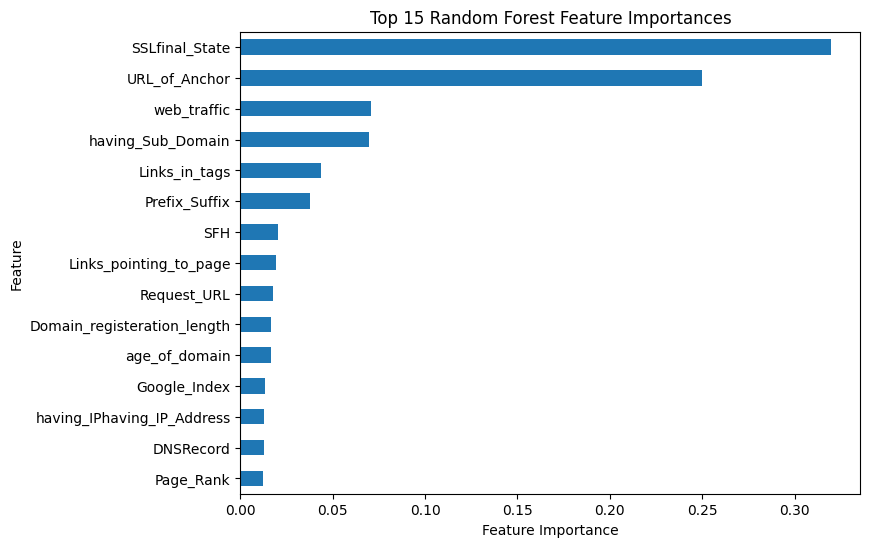

In [6]:
rf_feature_importance.head(15).sort_values(by="Importance").plot.barh(
    x="Feature",
    y="Importance",
    title="Top 15 Random Forest Feature Importances",
    legend=False,
    figsize=(8, 6)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

## Tuned Random Forest Model using Cross-Validation

In [18]:
param_grid_rf = {
    "n_estimators": [100, 125, 150, 175, 200],
    "max_depth": [10, 15, 20, 25, 30, 35],
    "max_features": ["sqrt", X.shape[1] // 2, X.shape[1] // 3],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring="accuracy", n_jobs=-1)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters")
print("---------------")
print(grid_search_rf.best_params_)
print()

print("Best Cross-Validation Accuracy")
print("------------------------------")
print(grid_search_rf.best_score_)
print()

Best Parameters
---------------
{'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 125}

Best Cross-Validation Accuracy
------------------------------
0.9706021757313614



In [20]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
error_rate_rf_tuned = 1 - accuracy_rf_tuned

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy:", accuracy_rf_tuned)
print("Error Rate:", error_rate_rf_tuned)
print()

print("Confusion Matrix:")
M_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned, labels=[-1, 1])

ConfusionMatrix_rf_tuned = pd.DataFrame(M_rf_tuned, index=["Legitimate (-1)", "Phishing (1)"], columns=["Legitimate (-1)", "Phishing (1)"])

ConfusionMatrix_rf_tuned["total"] = ConfusionMatrix_rf_tuned.sum(axis=1)

print(ConfusionMatrix_rf_tuned)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned, labels=[-1, 1], target_names=["Legitimate (-1)", "Phishing (1)"]))

Tuned Random Forest Results
---------------------------
Accuracy: 0.9742198100407056
Error Rate: 0.02578018995929443

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              942            38    980
Phishing (1)                  19          1212   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.98      0.96      0.97       980
   Phishing (1)       0.97      0.98      0.98      1231

       accuracy                           0.97      2211
      macro avg       0.97      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



## Interpret Tuned Random Forest Feature Importance

In [21]:
rf_tuned_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

rf_tuned_feature_importance = rf_tuned_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Most Important Features for Tuned Random Forest")
print("------------------------------------------------------")
print(rf_tuned_feature_importance.head(15))

Top 15 Most Important Features for Tuned Random Forest
------------------------------------------------------
                        Feature  Importance
7                SSLfinal_State    0.333765
13                URL_of_Anchor    0.235682
25                  web_traffic    0.073700
6             having_Sub_Domain    0.067040
14                Links_in_tags    0.042879
5                 Prefix_Suffix    0.040184
15                          SFH    0.019704
28       Links_pointing_to_page    0.019142
12                  Request_URL    0.017630
8   Domain_registeration_length    0.016712
23                age_of_domain    0.016288
27                 Google_Index    0.012802
0    having_IPhaving_IP_Address    0.012742
24                    DNSRecord    0.012690
26                    Page_Rank    0.011751


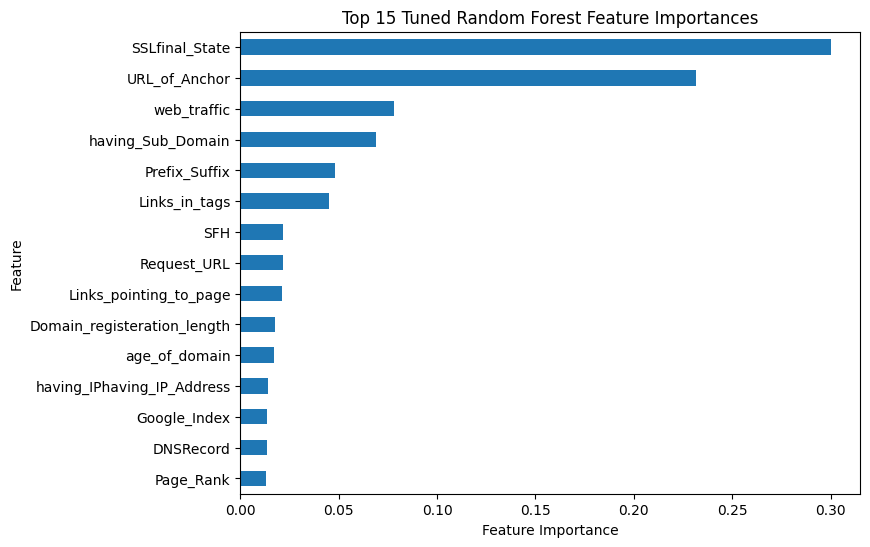

In [10]:
rf_tuned_feature_importance.head(15).sort_values(by="Importance").plot.barh(
    x="Feature",
    y="Importance",
    title="Top 15 Tuned Random Forest Feature Importances",
    legend=False,
    figsize=(8, 6)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

## Random Forest with Feature Engineering

In [27]:
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)

X_train_interactions_rf = poly.fit_transform(X_train)
X_test_interactions_rf = poly.transform(X_test)

interaction_feature_names_rf = poly.get_feature_names_out(X.columns)

print("Original number of features:", X_train.shape[1])
print("Number of features after adding interaction terms:", X_train_interactions_rf.shape[1])

Original number of features: 30
Number of features after adding interaction terms: 495


In [28]:
param_grid_rf_interactions = {
    "n_estimators": [100, 125, 150, 175, 200],
    "max_depth": [10, 15, 20, 25, 30, 35],
    "max_features": ["sqrt", X.shape[1] // 2, X.shape[1] // 3],
}

rf_interactions = RandomForestClassifier(random_state=42, n_jobs=-1)


grid_search_rf_interactions = GridSearchCV(estimator=rf_interactions, param_grid=param_grid_rf_interactions, cv=5, scoring="accuracy", n_jobs=-1)

grid_search_rf_interactions.fit(X_train_interactions_rf, y_train)

print("Best Parameters for Random Forest with Interaction Features")
print("-----------------------------------------------------------")
print(grid_search_rf_interactions.best_params_)
print()

print("Best Cross-Validation Accuracy")
print("------------------------------")
print(grid_search_rf_interactions.best_score_)
print()

Best Parameters for Random Forest with Interaction Features
-----------------------------------------------------------
{'max_depth': 30, 'max_features': 10, 'n_estimators': 125}

Best Cross-Validation Accuracy
------------------------------
0.9711675947502103



In [29]:
best_rf_interactions = grid_search_rf_interactions.best_estimator_

y_pred_rf_interactions_tuned = best_rf_interactions.predict(X_test_interactions_rf)

accuracy_rf_interactions_tuned = accuracy_score(y_test, y_pred_rf_interactions_tuned)
error_rate_rf_interactions_tuned = 1 - accuracy_rf_interactions_tuned

print("Tuned Random Forest with Interaction Features Results")
print("-----------------------------------------------------")
print("Accuracy:", accuracy_rf_interactions_tuned)
print("Error Rate:", error_rate_rf_interactions_tuned)
print()

print("Confusion Matrix:")
M_rf_interactions_tuned = confusion_matrix(y_test, y_pred_rf_interactions_tuned, labels=[-1, 1])

ConfusionMatrix_rf_interactions_tuned = pd.DataFrame(
    M_rf_interactions_tuned,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)

ConfusionMatrix_rf_interactions_tuned["total"] = ConfusionMatrix_rf_interactions_tuned.sum(axis=1)

print(ConfusionMatrix_rf_interactions_tuned)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf_interactions_tuned,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Tuned Random Forest with Interaction Features Results
-----------------------------------------------------
Accuracy: 0.9746720940750792
Error Rate: 0.025327905924920846

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              943            37    980
Phishing (1)                  19          1212   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.98      0.96      0.97       980
   Phishing (1)       0.97      0.98      0.98      1231

       accuracy                           0.97      2211
      macro avg       0.98      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



## Interpret Random Forest with Interaction Features

In [30]:
rf_interactions_tuned_feature_importance = pd.DataFrame({
    "Feature": interaction_feature_names_rf,
    "Importance": best_rf_interactions.feature_importances_
})

rf_interactions_tuned_feature_importance = rf_interactions_tuned_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Most Important Features for Tuned Random Forest with Interaction Features")
print("-------------------------------------------------------------------------------")
print(rf_interactions_tuned_feature_importance.head(15))

Top 15 Most Important Features for Tuned Random Forest with Interaction Features
-------------------------------------------------------------------------------
                                     Feature  Importance
13                             URL_of_Anchor    0.037471
232                SSLfinal_State RightClick    0.031388
7                             SSLfinal_State    0.023986
349                 URL_of_Anchor RightClick    0.023731
234                    SSLfinal_State Iframe    0.021858
351                     URL_of_Anchor Iframe    0.021659
358         URL_of_Anchor Statistical_report    0.020206
147  double_slash_redirecting SSLfinal_State    0.020056
172             Prefix_Suffix SSLfinal_State    0.016093
288                       port URL_of_Anchor    0.015793
100         Shortining_Service URL_of_Anchor    0.015035
121          having_At_Symbol SSLfinal_State    0.013840
178              Prefix_Suffix URL_of_Anchor    0.013821
239              SSLfinal_State Google_In

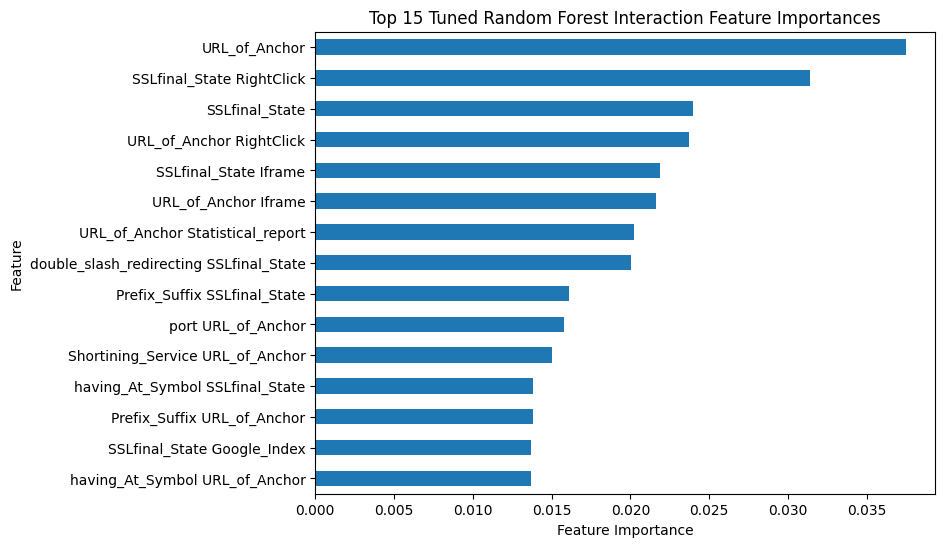

In [31]:
rf_interactions_tuned_feature_importance.head(15).sort_values(by="Importance").plot.barh(
    x="Feature",
    y="Importance",
    title="Top 15 Tuned Random Forest Interaction Feature Importances",
    legend=False,
    figsize=(8, 6)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()